<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/17_dropout_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout


In [2]:
X_train=np.linspace(-1,1,20)

In [3]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285,-0.2443 , -0.02445,
                    0.00135, -0.2006 ,  0.07475,-0.1422 ,  0.06515,  0.15265,
                    0.3521 ,  0.28415,0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [4]:
X_test=np.linspace(-1,1,20)

In [5]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                  0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

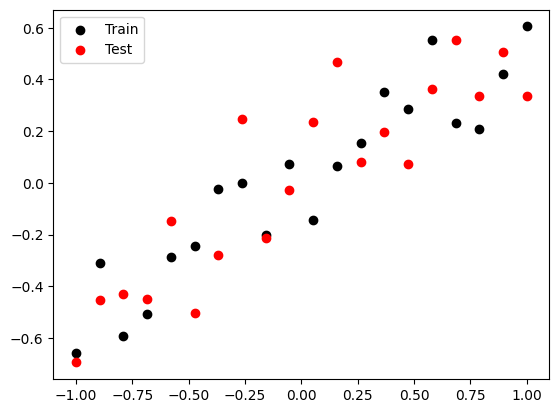

In [6]:
plt.scatter(X_train, y_train,c="black", label="Train")
plt.scatter(X_test, y_test,c="red", label="Test")
plt.legend()
plt.show()

In [17]:
model=Sequential()
model.add(Dense(128,activation="relu",input_dim=1))
model.add(Dense(128,activation="relu"))
model.add(Dense(128,activation="relu"))
model.add(Dense(1,activation="linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,409 (130.50 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
adam=keras.optimizers.Adam(learning_rate=0.01)

In [20]:
model.compile(loss='mse', optimizer=adam,metrics=['mse'])

In [21]:
history=model.fit(X_train, y_train,validation_data=(X_test, y_test), epochs=500,verbose=0)

In [22]:
X_train.shape

(20,)

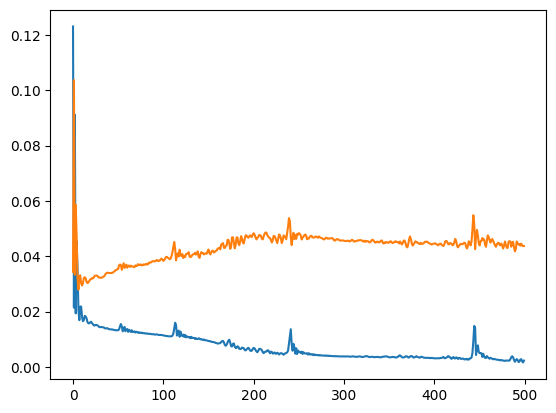

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


**Evaluate Model Performaence**

In [24]:
_, train_mse=model.evaluate(X_train, y_train,verbose=0)
_, test_mse=model.evaluate(X_test, y_test,verbose=0)

In [27]:
print("train loss {}".format(train_mse))
print("Test loss {}".format(test_mse))

train loss 0.002055075019598007
Test loss 0.04369848221540451


In [28]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


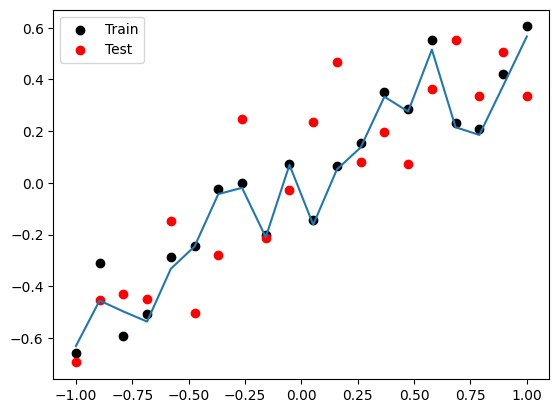

In [29]:
plt.scatter(X_train, y_train,c="black", label="Train")
plt.scatter(X_test, y_test,c="red", label="Test")
plt.plot(X_test,y_pred)
plt.legend()
plt.show()

**Drop Out**

In [36]:
model=Sequential()
model.add(Dense(128,activation='relu', input_dim=1))
model.add(Dropout(0.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

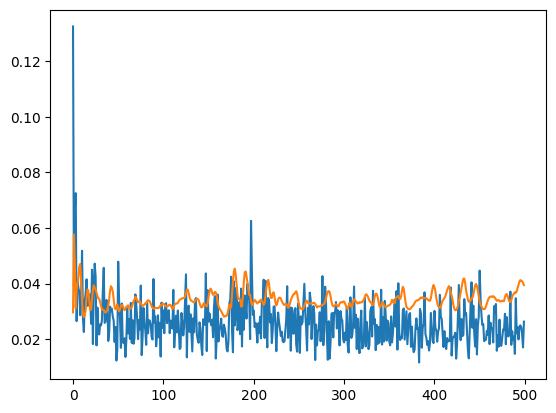

In [38]:
adam=keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='mse', optimizer=adam,metrics=['mse'])

history=model.fit(X_train, y_train,validation_data=(X_test, y_test), epochs=500,verbose=0)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [39]:
_, train_mse=model.evaluate(X_train, y_train,verbose=0)
_, test_mse=model.evaluate(X_test, y_test,verbose=0)


print("Train Losst ={}".format(train_mse))
print("Test Losst ={}".format(test_mse))

Train Losst =0.016438458114862442
Test Losst =0.039451755583286285


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


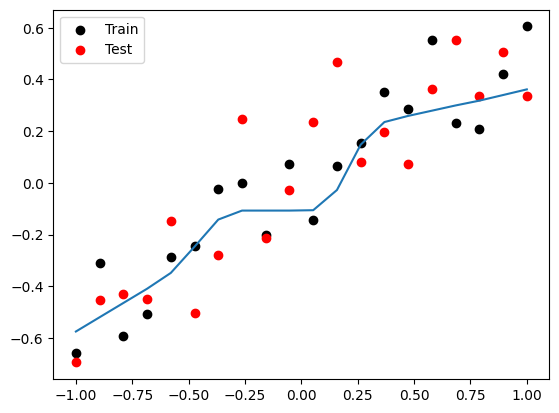

In [40]:
y_pred=model.predict(X_test)
plt.scatter(X_train, y_train,c="black", label="Train")
plt.scatter(X_test, y_test,c="red", label="Test")
plt.plot(X_test,y_pred)
plt.legend()
plt.show()